# Test 1: Block-only AUC

Question: **Which immune compartments are sufficient to classify HIV status on their own?**

This is not a synthetic-data test yet. It first establishes which biology-shaped feature groups carry real cohort signal. Synthetic preservation should be tested only after this real-cohort structure is clear.

In [1]:
from pathlib import Path
import os
if (Path.cwd() / 'data_synthesis' / 'notebooks').exists():
    os.chdir(Path.cwd() / 'data_synthesis' / 'notebooks')
%run ./00_block_auc_common.ipynb


C:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


Loaded HIV matrix: 91 participants x 63 features; class counts HIV-=23, PLWH=68


## Blocks in this test

Primary block-only test:

- serum IgG alone
- saliva IgA alone
- cytokines alone
- ACE2 alone
- production/decay alone

Important clarification: **serum IgG** contains the repeated blood IgG Spike/RBD visit measurements. **Production/decay** is separate because those columns are derived dynamic summaries, not raw serum IgG visit values.

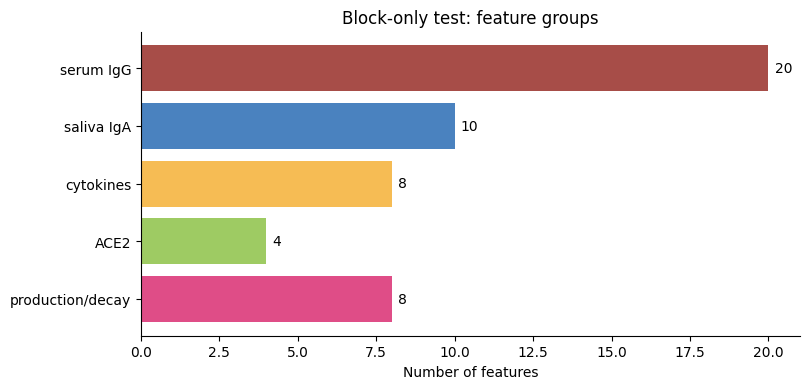

**serum IgG** (20): V1_blood_IgGspike, V4_blood_IgGspike, V4a_blood_IgGspike, V6_blood_IgGspike, V8_blood_IgGspike, V8a_blood_IgGspike, V8b_blood_IgGspike, V9_blood_IgGspike, V10_blood_IgGspike, V11_blood_IgGspike, V1_blood_IgGRBD, V4_blood_IgGRBD, V4a_blood_IgGRBD, V6_blood_IgGRBD, V8_blood_IgGRBD, V8a_blood_IgGRBD, V8b_blood_IgGRBD, V9_blood_IgGRBD, V10_blood_IgGRBD, V11_blood_IgGRBD

**saliva IgA** (10): V4_Saliva_IgAspike, V4_Saliva_IgARBD, V5_Saliva_IgAspike, V5_Saliva_IgARBD, V8_Saliva_IgAspike, V8_Saliva_IgARBD, V8b_Saliva_IgAspike, V8b_Saliva_IgARBD, V9_Saliva_IgAspike, V9_Saliva_IgARBD

**cytokines** (8): V8_IFNg, V9_IFNg, V8_IL2, V9_IL2, V9Dual, V8Dual, IFNG_production, Il2_production

**ACE2** (4): V7_ACE2, V8_ACE2, V8b_ACE2, V9_ACE2

**production/decay** (8): spikeProduction_D1D2, spikeDecay_D1D2, spikeProduction_D3, spikeDecay_D3, RBDProduction_D1D2, RBDDecay_D1D2, RBDProduction_D3, RBDDecay_D3

In [2]:
TEST_BLOCKS = PRIMARY_BLOCK_ONLY
plot_block_definitions(TEST_BLOCKS, title='Block-only test: feature groups')
show_block_members(TEST_BLOCKS)


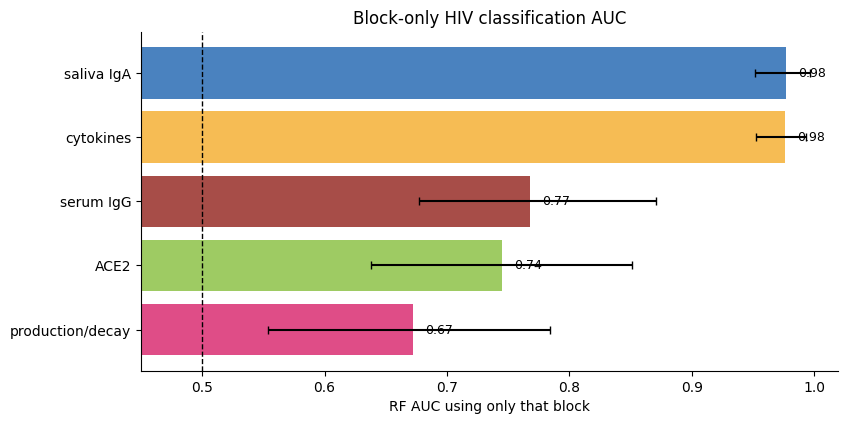

In [3]:
block_only_auc = evaluate_block_only(TEST_BLOCKS)
plot_auc_bars(
    block_only_auc,
    title='Block-only HIV classification AUC',
    xlabel='RF AUC using only that block',
)


## How to read this plot

A high AUC means the block is sufficient to classify HIV status by itself. A low AUC does **not** mean the block is biologically irrelevant; it may still contribute through synergy with other blocks. That is why this test should be interpreted before, not instead of, cross-block synergy.